# Markov Decision Processes to Optimising Call Centre Operation

### Scenario

I am the manager of a call center.  
We have:
- 2 agents: **A** and **B**
- 2 waiting queues (one for each agent), with 10 spaces in each queue.

### Assumptions

- **States**:  
  $\text{states} = (QA,\, QB)$  
  where each value ranges from 0 to 10.  
  (0 means idle; 1 means busy; 2–10 means the agent is busy and the queue has customer waiting.)

- **Actions**:  
$\text{actions} = [\texttt{Assign\_A},\ \texttt{Assign\_B},\ \texttt{lost}]$


- **Types of Questions**:
  - **VIP**
  - **Common**

- **Service Rate ($\mu$)**:
  - $\mu_1$ = Service rate of Agent A for VIP  
  - $\mu_2$ = Service rate of Agent A for Common  
  - $\mu_3$ = Service rate of Agent B for VIP  
  - $\mu_4$ = Service rate of Agent B for Common

- **Arrival Rate ($\lambda$)**:
  - $\lambda$ represents the arrival rate of customers.

- **Service rate assumptions**:  
  $\mu_1 > \mu_3$ (A handles VIP faster than B)  
  $\mu_2 > \mu_4$ (A handles Common faster than B)

- **Objective**:  
  Optimize the call center operations by **maximizing** the Reward_function_function function:  
  $R(s, a)$  
  where $s$ is the state, and $a$ is the selected action.





In [14]:
import random
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.patches import Patch
import pandas as pd
from collections import defaultdict

In [15]:
# constraint
# minute is the unit in this simulation

QUEUE_LIMIT = 10   # the lenth of each queue
ARRIVAL_RATE = 3/20  # Poisson distribution 
SERVICE_RATE_A = {"VIP": 1/20, "Common": 1/10}      # service rate of A # VIP:1 call / 20 mins, Common: 1 call / 10 mins
SERVICE_RATE_B = {"VIP": 1/30, "Common": 1/15}      # service rate of B # VIP:1 call / 30 mins, Common: 1 call / 15 mins
VIP_PROB = 0.3  # ratio of VIP = 0.3, ratio of Common = 0.7
SIM_TIME = 1440  # assume 1 day, so it is 24 hours = 60 mins * 24 = 1440 mins

np.random.seed(42)
random.seed(42)

In [16]:
# Initial state

agent_busy_until = {"A": 0, "B": 0} # when current_time over this time, it means the agent is available
queue_A, queue_B = [], []
simulation_record = []

current_time = 0

In [17]:
# Next Arrival
def Generate_arrival(current):
    return current + np.random.exponential(1 / ARRIVAL_RATE)    # Poisson distribution

next_arrival_time = Generate_arrival(current_time)

In [18]:
# Current state is represented with a small bracket(queue_A, queue_B)
# If the Agent is currently busy then it represents 1, otherwise it is idle so that it shows 0
# the state is either 1 or 0 plus the lenth of the waiting queue.

def Get_state():
    return (len(queue_A) + (1 if agent_busy_until["A"] > current_time else 0),
            len(queue_B) + (1 if agent_busy_until["B"] > current_time else 0))

In [19]:
# Record to the CSV file(log)

while current_time < SIM_TIME:
    # to check if A is available at the moment AND update customer for agent A
    if agent_busy_until["A"] <= current_time and queue_A:
        customer = queue_A.pop(0)
        before_state = Get_state()
        duration = np.random.exponential(1 / SERVICE_RATE_A[customer["customer_type"]])
        agent_busy_until["A"] = current_time + duration
        after_state = Get_state()
        customer.update({
            "agent": "A",
            "call_start_time": current_time,
            "call_end_time": current_time + duration,
            "action": "assign A",
            "before_state": before_state,
            "after_state": after_state
        })
        simulation_record.append(customer)

    # to check if B is available at the moment AND update customer for agent B
    if agent_busy_until["B"] <= current_time and queue_B:
        customer = queue_B.pop(0)
        before_state = Get_state()
        duration = np.random.exponential(1 / SERVICE_RATE_B[customer["customer_type"]])
        agent_busy_until["B"] = current_time + duration
        after_state = Get_state()
        customer.update({
            "agent": "B",
            "call_start_time": current_time,
            "call_end_time": current_time + duration,
            "action": "assign B",
            "before_state": before_state,
            "after_state": after_state
        })
        simulation_record.append(customer)

    # to generate the new arrival customer type and create the new customer information
    if current_time >= next_arrival_time:
        customer_type = "VIP" if random.random() < VIP_PROB else "Common"
        before_state = Get_state()
        customer = {
            "timestamp": round(current_time, 2),
            "customer_type": customer_type,
            "agent": None,
            "call_start_time": None,
            "call_end_time": None,
            "action": None,
            "before_state": before_state,
            "after_state": None
        }

        if agent_busy_until["A"] <= current_time:
            duration = np.random.exponential(1 / SERVICE_RATE_A[customer_type])
            agent_busy_until["A"] = current_time + duration
            customer.update({
                "agent": "A",
                "call_start_time": current_time,
                "call_end_time": current_time + duration,
                "action": "assign A",
                "after_state": Get_state()
            })
            simulation_record.append(customer)

        elif agent_busy_until["B"] <= current_time:
            duration = np.random.exponential(1 / SERVICE_RATE_B[customer_type])
            agent_busy_until["B"] = current_time + duration
            customer.update({
                "agent": "B",
                "call_start_time": current_time,
                "call_end_time": current_time + duration,
                "action": "assign B",
                "after_state": Get_state()
            })
            simulation_record.append(customer)

        else:
            if len(queue_A) < QUEUE_LIMIT+1:
                customer.update({
                    "action": "queue A",
                    "after_state": Get_state()
                })
                queue_A.append(customer)
            
            elif len(queue_B) < QUEUE_LIMIT+1:
                customer.update({
                    "action": "queue B",
                    "after_state": Get_state()
                })
                queue_B.append(customer)
            
            else:
                customer.update({
                    "action": "lost",
                    "after_state": Get_state()
                })
                simulation_record.append(customer)

        next_arrival_time = Generate_arrival(current_time)

    current_time += 0.1 


with open("call_center_poisson_simulation_record.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["timestamp", "customer_type", "before_state", "action", "agent", "call_start_time", "call_end_time", "after_state"])
    writer.writeheader()
    writer.writerows(simulation_record)

In [20]:
# calculate transition probabilities

num_transit = {}

# Collect the times of transition states when taking the specific actions
for record in simulation_record:
    key = (record['before_state'], record['action'])
    next_state = record['after_state']
    if key not in num_transit:
        num_transit[key] = {}
    if next_state not in num_transit[key]:
        num_transit[key][next_state] = 0
    num_transit[key][next_state] += 1

# Calculate the transition probabilities
transition_probs = {}

for key in num_transit:
    total = sum(num_transit[key].values())
    transition_probs[key] = {s_: count / total for s_, count in num_transit[key].items()}

In [21]:
# Reward_function , Value Iteration, Policy dictionary 

states = [(qA, qB) for qA in range(QUEUE_LIMIT + 1) for qB in range(QUEUE_LIMIT + 1)]
gamma = 0.9   # discount factor, usually it is set up as 0.9 or 0.95
theta = 0.01  # the iteration threshold


def generate_valid_actions(state):
    qA, qB = state
    actions = []
    if qA < QUEUE_LIMIT:
        actions.append("assign A")
    if qB < QUEUE_LIMIT:
        actions.append("assign B")
    # Take action "lost", when the queues are all full.
    if not actions:
        actions.append("lost") 
    return actions



def Reward_function_function(state, action):
    qA, qB = state
    if action == "assign A":
        if qA >= QUEUE_LIMIT:
            return -100
        return -5 - qA
    elif action == "assign B":
        if qB >= QUEUE_LIMIT:
            return -100
        return -5 - qB
    elif action == "lost":
        return -200 
    return 0


def get_transition(state, action):
    qA, qB = state
    if action == "assign A":
        return {(min(qA + 1, QUEUE_LIMIT), qB): 1.0}
    elif action == "assign B":
        return {(qA, min(qB + 1, QUEUE_LIMIT)): 1.0}
    else:  # lost
        return {state: 1.0}

# Value iteration
V = {s: 0 for s in states}
policy = {}
convergence_list = []

for _ in range(1000):
    delta = 0
    V_new = {}
    for s in states:
        valid_actions = generate_valid_actions(s)
        action_values = {}
        for a in valid_actions:
            trans = get_transition(s, a)
            expected = sum(
                p * (Reward_function_function(s, a) + gamma * V[s_])
                for s_, p in trans.items()
            )
            action_values[a] = expected
        best_action = max(action_values, key=action_values.get)
        V_new[s] = action_values[best_action]
        policy[s] = best_action
        delta = max(delta, abs(V_new[s] - V[s]))
    V = V_new
    convergence_list.append(delta)
    if delta < theta:
        break

# Policy dictionary
for s in sorted(policy):
    print(f"{s}, {policy[s]}")



(0, 0), assign A
(0, 1), assign A
(0, 2), assign A
(0, 3), assign A
(0, 4), assign A
(0, 5), assign A
(0, 6), assign A
(0, 7), assign A
(0, 8), assign A
(0, 9), assign A
(0, 10), assign A
(1, 0), assign B
(1, 1), assign A
(1, 2), assign A
(1, 3), assign A
(1, 4), assign A
(1, 5), assign A
(1, 6), assign A
(1, 7), assign A
(1, 8), assign A
(1, 9), assign A
(1, 10), assign A
(2, 0), assign B
(2, 1), assign B
(2, 2), assign A
(2, 3), assign A
(2, 4), assign A
(2, 5), assign A
(2, 6), assign A
(2, 7), assign A
(2, 8), assign A
(2, 9), assign A
(2, 10), assign A
(3, 0), assign B
(3, 1), assign B
(3, 2), assign B
(3, 3), assign A
(3, 4), assign A
(3, 5), assign A
(3, 6), assign A
(3, 7), assign A
(3, 8), assign A
(3, 9), assign A
(3, 10), assign A
(4, 0), assign B
(4, 1), assign B
(4, 2), assign B
(4, 3), assign B
(4, 4), assign A
(4, 5), assign A
(4, 6), assign A
(4, 7), assign A
(4, 8), assign A
(4, 9), assign A
(4, 10), assign A
(5, 0), assign B
(5, 1), assign B
(5, 2), assign B
(5, 3), a

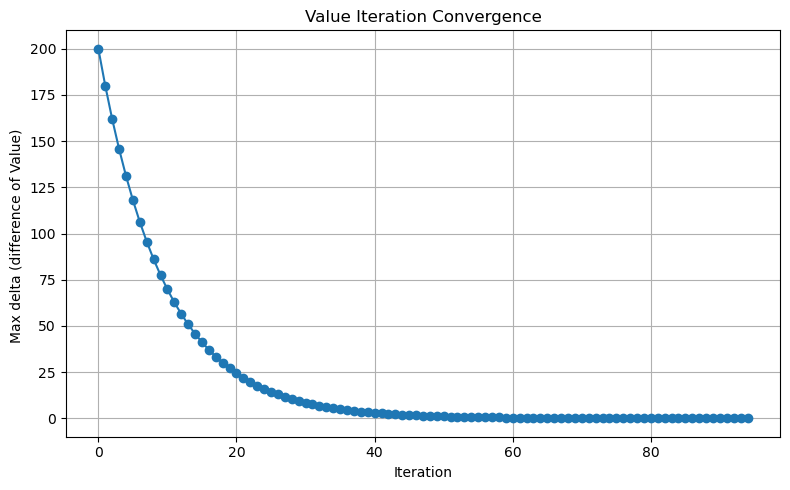

In [22]:
# Visualization # Convergence plot

plt.figure(figsize=(8, 5))
plt.plot(convergence_list, marker='o', linestyle='-', linewidth=1.5)
plt.title("Value Iteration Convergence")
plt.xlabel("Iteration")
plt.ylabel("Max delta (difference of Value) ")
plt.grid(True)
plt.tight_layout()
plt.show()


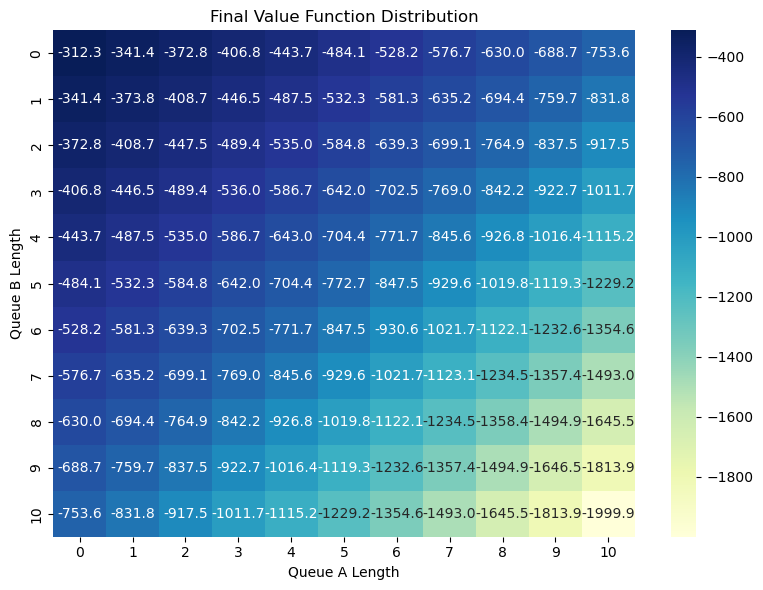

In [23]:
# Reward_function_function cumulative value 

# Get help from chatgpt on the design of the plot
value_grid = np.zeros((QUEUE_LIMIT + 1, QUEUE_LIMIT + 1))
for (qA, qB), v in V.items():
    value_grid[qB, qA] = v 

plt.figure(figsize=(8, 6))
sns.heatmap(value_grid, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Final Value Function Distribution")
plt.xlabel("Queue A Length")
plt.ylabel("Queue B Length")
plt.tight_layout()
plt.show()


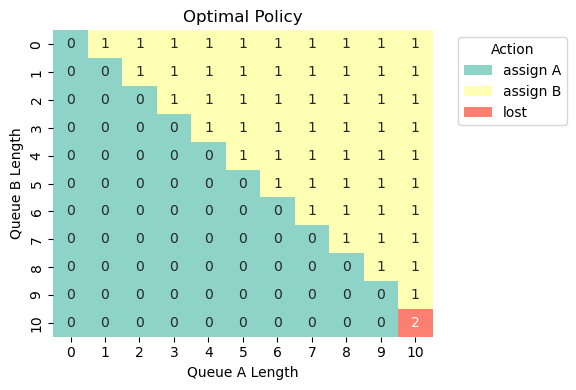

In [24]:
# plot the heatmap of optimal policy 

action_map = {"assign A": 0, "assign B": 1, "lost": 2}
action_colors = ["#8dd3c7", "#ffffb3", "#fb8072"]
lim_qa = max(s[0] for s in policy)
lim_qb = max(s[1] for s in policy)
policy_grid = np.full((lim_qb + 1, lim_qa + 1), -1)
for (qA, qB), action in policy.items():
    if action in action_map:
        policy_grid[qB, qA] = action_map[action]

# plot
plt.figure(figsize=(7, 4))  
sns.heatmap(policy_grid, annot=True, fmt='d', cmap=action_colors, cbar=False,
            xticklabels=range(lim_qa + 1), yticklabels=range(lim_qb + 1))
plt.title("Optimal Policy")
plt.xlabel("Queue A Length")
plt.ylabel("Queue B Length")

# Get help from chatgpt to adjust the legend layout
legend_elements = [
    Patch(facecolor=action_colors[0], label="assign A"),
    Patch(facecolor=action_colors[1], label="assign B"),
    Patch(facecolor=action_colors[2], label="lost"),
]
plt.legend(handles=legend_elements, title="Action", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


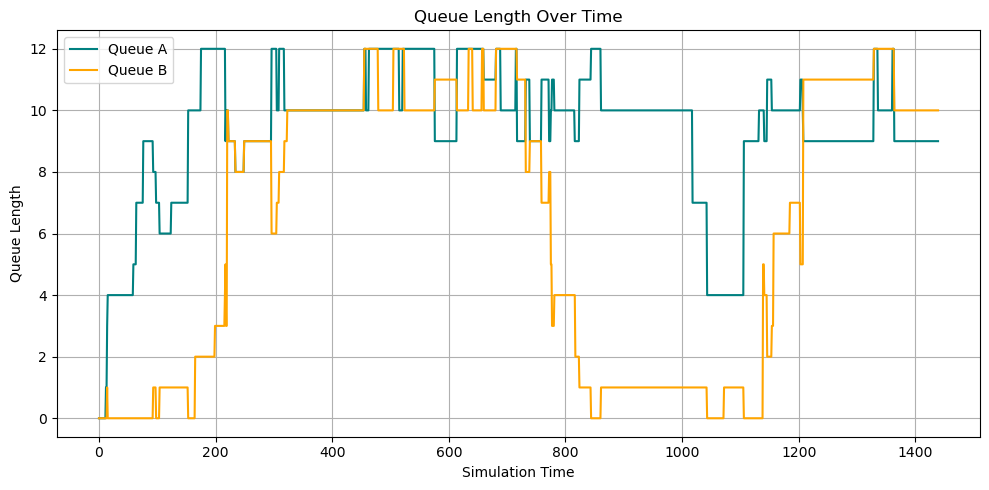

In [25]:


# time interval (this is continue)
time_interval_continue = np.arange(0, SIM_TIME, 1)

# to track the length of queue
qa_length = []
qb_length = []

last_qA = 0
last_qB = 0
simulation_record_index = 0

for timepoint in time_interval_continue:
    # iterate simulation_record until over the time
    while simulation_record_index < len(simulation_record) and simulation_record[simulation_record_index]['timestamp'] <= timepoint:
        if 'before_state' in simulation_record[simulation_record_index]:
            last_qA, last_qB = simulation_record[simulation_record_index]['before_state']
        elif 'after_state' in simulation_record[simulation_record_index]:
            last_qA, last_qB = simulation_record[simulation_record_index]['after_state']
        simulation_record_index += 1
    qa_length.append(last_qA)
    qb_length.append(last_qB)

# plot
plt.figure(figsize=(10, 5))
plt.plot(time_interval_continue, qa_length, label="Queue A", color="teal")
plt.plot(time_interval_continue, qb_length, label="Queue B", color="orange")
plt.xlabel("Simulation Time")
plt.ylabel("Queue Length")
plt.title("Queue Length Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:

total_wait_time = 0
wait_count = 0
queue_length_simulation_record = defaultdict(list)
agent_busy_time = {"A": 0, "B": 0}
last_time = 0
lost_count = 0
total_customers = 0

# Process the simulation_record
for features in simulation_record:
    if features["action"] == "lost":
        lost_count += 1
        continue

    total_customers += 1

    # waiting time = call_start_time - arrival time stamp
    if features["call_start_time"] is not None:
        wait_time = features["call_start_time"] - features["timestamp"]
        total_wait_time += wait_time
        wait_count += 1

    # calculate the service time of agent
    if features["agent"] == "A":
        agent_busy_time["A"] += features["call_end_time"] - features["call_start_time"]
    elif features["agent"] == "B":
        agent_busy_time["B"] += features["call_end_time"] - features["call_start_time"]

    # queue length at that time
    if features["before_state"] and isinstance(features["before_state"], tuple):
        qa, qb = features["before_state"]
        queue_length_simulation_record["A"].append((features["timestamp"], qa))
        queue_length_simulation_record["B"].append((features["timestamp"], qb))

    last_time = max(last_time, features.get("call_end_time", 0))

# performance
avg_waiting_time = total_wait_time / wait_count if wait_count > 0 else 0
avg_queue_length_A = sum(q for _, q in queue_length_simulation_record["A"]) / len(queue_length_simulation_record["A"]) if queue_length_simulation_record["A"] else 0
avg_queue_length_B = sum(q for _, q in queue_length_simulation_record["B"]) / len(queue_length_simulation_record["B"]) if queue_length_simulation_record["B"] else 0
utilization_A = agent_busy_time["A"] / last_time if last_time > 0 else 0
utilization_B = agent_busy_time["B"] / last_time if last_time > 0 else 0
lost_rate = lost_count / (lost_count + total_customers) if (lost_count + total_customers) > 0 else 0

# summary
print("ARRIVAL_RATE is 3/20 high busy level")
print("--------------------------------------------")
print(f"Average Waiting Time: {avg_waiting_time:.2f} seconds")
print(f"Average Queue Length A: {avg_queue_length_A:.2f}")
print(f"Average Queue Length B: {avg_queue_length_B:.2f}")
print(f"Utilization Rate A: {utilization_A:.2%}")
print(f"Utilization Rate B: {utilization_B:.2%}")
print(f"Customer Lost Rate: {lost_rate:.2%}")


ARRIVAL_RATE is 3/20 high busy level
--------------------------------------------
Average Waiting Time: 114.89 seconds
Average Queue Length A: 9.48
Average Queue Length B: 5.96
Utilization Rate A: 96.33%
Utilization Rate B: 92.50%
Customer Lost Rate: 14.42%
